In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("ASGN3/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
x_train=df.drop('label',axis=1)
y_train=df['label']
x_train=np.array(x_train).reshape(x_train.shape[0],28,28)
y_train=np.array(y_train)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,MaxPooling2D,Conv2D,Flatten
from tensorflow.keras.losses import sparse_categorical_crossentropy
model=Sequential()
model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 143s 75ms/step - loss: 0.9250 - accuracy: 0.8533
Epoch 2/3
1875/1875 [==============================] - 139s 74ms/step - loss: 0.2989 - accuracy: 0.8930
Epoch 3/3
1875/1875 [==============================] - 139s 74ms/step - loss: 0.2658 - accuracy: 0.9023


In [14]:
df=pd.read_csv("ASGN3/fashion-mnist_test.csv")
x_test=df.drop('label',axis=1)
y_test=df['label']
x_test=np.array(x_test).reshape(x_test.shape[0],28,28)
y_test=np.array(y_test)

In [15]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 5s 16ms/step - loss: 0.3020 - accuracy: 0.8922


[0.30203816294670105, 0.8921999931335449]

1/1 [==============================] - 0s 48ms/step
Correct


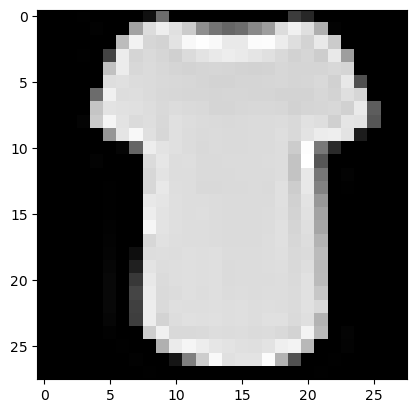

In [17]:
ind=343
image=x_test[ind]
truelabel=y_test[ind]
pred=np.argmax(model.predict(np.expand_dims(image,axis=0)))
if(pred==truelabel):
    print("Correct")
else:
    print("Wrong")

plt.imshow(image,cmap='gray')